# Python 3 — Cálculo Multivariable
## Laboratorio: Métodos de Bisección y Newton

**Funciones de trabajo:**
- $f(x) = x^3 - x - 2$
- $g(x) = e^{-x} - x$
- $h(x) = x^3 - 2x + 2$

In [1]:
# ============================================================
# IMPORTACIONES Y DEFINICIÓN DE LOS MÉTODOS NUMÉRICOS
# ============================================================
import sympy as sp
import numpy as np
from tabulate import tabulate

x = sp.symbols('x')

# ----------------------------------------------------------
# Método de Bisección
# ----------------------------------------------------------
def MetodoBiseccion(Funcion, xizq, xder, tolerancia=1e-6, MaxPasos=100):

    Funcion = sp.lambdify(x, Funcion)   # Evaluación numérica
    fa = Funcion(xizq)
    fb = Funcion(xder)
    Pasos = 0
    ErrorAprox = 2
    Tabla = []

    print('\nTabla de Resultados del Método de Bisección')

    while ErrorAprox > tolerancia and Pasos < MaxPasos:

        xc = 0.5 * (xizq + xder)
        fc = Funcion(xc)
        Pasos += 1
        ErrorAprox = abs(xder - xizq) / 2

        Tabla.append([Pasos, xizq, xc, xder, fa, fc, fb, ErrorAprox])

        if abs(fa) < 1e-16:
            xc = xizq
            print('\n La raíz se encuentra en el extremo izquierdo:', xizq)
            break

        if abs(fb) < 1e-16:
            xc = xder
            print('\n La raíz se encuentra en el extremo derecho:', xder)
            break

        if fa * fc < 0:
            xder = xc
            fb = fc
        elif fc * fb < 0:
            xizq = xc
            fa = fc
        else:
            print('El Método de Bisección falla: no hay cambio de signo en el intervalo.\n')
            break

    print(tabulate(Tabla,
                   headers=['Paso', 'a', 'c', 'b', 'f(a)', 'f(c)', 'f(b)', 'Error Aprox'],
                   floatfmt=['3d', '11.8f', '11.8f', '11.8f', '8.2e', '8.2e', '8.2e', '8.2e'],
                   tablefmt='rounded_grid',
                   numalign='center'))

    print('\n Después de {:3d} pasos, la raíz aproximada con Bisección es:  {:18.15f}\n'.format(Pasos, xc))
    return xc


# ----------------------------------------------------------
# Método de Newton
# ----------------------------------------------------------
def MetodoNewton(Funcion, xest=0.0, TOL=1e-10, MaxPasos=100):

    Derivada = sp.diff(Funcion, x)
    print()
    print('La función derivada obtenida con sympy es:')
    sp.pprint(Derivada)
    print()

    Funcion  = sp.lambdify(x, Funcion)
    Derivada = sp.lambdify(x, Derivada)

    Pasos = 0
    Error = 2
    Tabla = []

    print('\nTabla de Resultados del Método de Newton')

    while Error > TOL and Pasos < MaxPasos:
        Pasos += 1
        fxo  = Funcion(xest)
        dfxo = Derivada(xest)
        x1   = xest - fxo / dfxo
        Error = abs(xest - x1)
        xest  = x1
        Tabla.append([Pasos, xest, Error])

    print(tabulate(Tabla,
                   headers=['Paso', 'Estimación', 'Error Aproximado'],
                   floatfmt=['3d', '18.14f', '8.2e'],
                   tablefmt='rounded_grid',
                   numalign='center'))

    if Pasos >= MaxPasos:
        print('El Método de Newton NO pudo aproximar una raíz. Intente con otra estimación.\n')
    else:
        print('Después de {:2d} pasos, la raíz aproximada con Newton es: {:18.15f}\n'.format(Pasos, xest))

    print()
    return xest

---
## Problema 1
Usando los métodos de Bisección y Newton, aproxime el cero de:
- $f(x) = x^3 - x - 2$
- $g(x) = e^{-x} - x$

con precisión de **4 decimales** (tolerancia $= 5 \times 10^{-5}$).

Funciones del problema 1:
f(x) = 
 3        
x  - x - 2
g(x) = 
      -x
-x + ℯ  


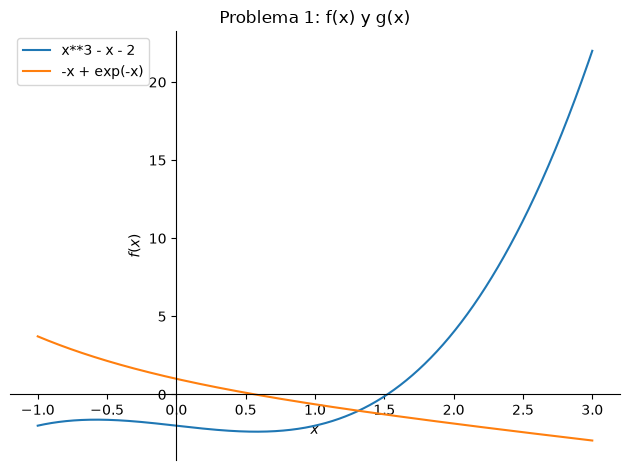

In [2]:
# ----------------------------------------------------------
# Problema 1 — Definición de funciones y análisis previo
# ----------------------------------------------------------
f = x**3 - x - 2
g = sp.exp(-x) - x

print('Funciones del problema 1:')
print('f(x) = '), sp.pprint(f)
print('g(x) = '), sp.pprint(g)

# Graficamos para identificar los intervalos con raíces
p1 = sp.plot(f, g, (x, -1, 3),
             legend=True, title='Problema 1: f(x) y g(x)',
             show=True)

In [ ]:
# ----------------------------------------------------------
# Problema 1a — Bisección para f(x) = x³ - x - 2
# Intervalo [1, 2]: f(1) = -2 < 0,  f(2) = 4 > 0  → hay raíz
# ----------------------------------------------------------
TOL4 = 5e-5   # Precisión de 4 decimales

print('=' * 60)
print('BISECCIÓN — f(x) = x³ - x - 2,  intervalo [1, 2]')
print('=' * 60)
raiz_f_bis = MetodoBiseccion(f, 1, 2, tolerancia=TOL4)

In [ ]:
# ----------------------------------------------------------
# Problema 1a — Newton para f(x) = x³ - x - 2
# Estimación inicial x0 = 1 (extremo izquierdo del intervalo)
# ----------------------------------------------------------
print('=' * 60)
print('NEWTON — f(x) = x³ - x - 2,  x0 = 1')
print('=' * 60)
raiz_f_new = MetodoNewton(f, xest=1.0, TOL=TOL4)

In [ ]:
# ----------------------------------------------------------
# Problema 1a — Bisección para g(x) = e^(-x) - x
# Intervalo [0, 1]: g(0) = 1 > 0,  g(1) ≈ -0.632 < 0  → hay raíz
# ----------------------------------------------------------
print('=' * 60)
print('BISECCIÓN — g(x) = e^(-x) - x,  intervalo [0, 1]')
print('=' * 60)
raiz_g_bis = MetodoBiseccion(g, 0, 1, tolerancia=TOL4)

In [ ]:
# ----------------------------------------------------------
# Problema 1a — Newton para g(x) = e^(-x) - x
# Estimación inicial x0 = 0
# ----------------------------------------------------------
print('=' * 60)
print('NEWTON — g(x) = e^(-x) - x,  x0 = 0')
print('=' * 60)
raiz_g_new = MetodoNewton(g, xest=0.0, TOL=TOL4)

### Problema 1b — ¿Cuál es el mejor método para cada función?

**Para $f(x) = x^3 - x - 2$:**  
El **Método de Newton** es superior. La función $f$ es suave y su derivada $f'(x) = 3x^2 - 1$ es fácil de calcular. Newton converge en muy pocos pasos (convergencia cuadrática), mientras que Bisección requiere bastantes más iteraciones para alcanzar la misma precisión.

**Para $g(x) = e^{-x} - x$:**  
El **Método de Newton** también converge rápidamente aquí, ya que $g$ es igualmente suave. Sin embargo, si se desconoce una buena estimación inicial, la **Bisección** garantiza siempre convergencia porque $g$ cambia de signo en $[0, 1]$. Para esta función ambos métodos son eficientes, pero Newton es más rápido cuando la estimación inicial es adecuada.

---
## Problema 2
Aproxime el valor de $x$ a **12 decimales** con el Método de Newton para:
$$h(x) = x^3 - 2x + 2$$
usando distintas estimaciones iniciales.

In [ ]:
# ----------------------------------------------------------
# Problema 2 — Definición y gráfica de h(x)
# ----------------------------------------------------------
h = x**3 - 2*x + 2

print('h(x) = '), sp.pprint(h)

sp.plot(h, (x, -2.5, 2),
        title='h(x) = x³ - 2x + 2',
        xlabel='x', ylabel='h(x)')

TOL12 = 5e-13   # Precisión de 12 decimales

In [ ]:
# ----------------------------------------------------------
# Problema 2a — Newton con x0 = 0
# ----------------------------------------------------------
print('=' * 60)
print('NEWTON — h(x),  x0 = 0')
print('=' * 60)
raiz_h_0 = MetodoNewton(h, xest=0.0, TOL=TOL12)

In [ ]:
# ----------------------------------------------------------
# Problema 2b — Newton con x0 = 0.7
# ----------------------------------------------------------
print('=' * 60)
print('NEWTON — h(x),  x0 = 0.7')
print('=' * 60)
raiz_h_07 = MetodoNewton(h, xest=0.7, TOL=TOL12)

In [ ]:
# ----------------------------------------------------------
# Problema 2c — Newton con x0 = -1.5
# ----------------------------------------------------------
print('=' * 60)
print('NEWTON — h(x),  x0 = -1.5')
print('=' * 60)
raiz_h_m15 = MetodoNewton(h, xest=-1.5, TOL=TOL12)

### Problema 2d — Diferencia entre las estimaciones iniciales

La función $h(x) = x^3 - 2x + 2$ tiene un **único cero real** aproximadamente en $x \approx -1.7693$. Sus puntos críticos están en $x = \pm\sqrt{2/3} \approx \pm 0.8165$, donde la derivada $h'(x) = 3x^2 - 2$ se anula.

- **$x_0 = 0$:** La estimación cae muy cerca de un punto crítico de $h$, donde $h'(0) = -2$ y la siguiente iteración salta a $x_1 = 1$, de donde regresa a $x_0 = 0$. El método **cicla indefinidamente** (no converge).

- **$x_0 = 0.7$:** Esta estimación también está cerca del máximo local ($x \approx 0.816$), donde la derivada es pequeña y negativa. La corrección de Newton propulsa la estimación lejos del intervalo, y el método puede **no converger** o tardar muchos pasos antes de escapar hacia la raíz real.

- **$x_0 = -1.5$:** Esta estimación está cerca de la raíz real ($x \approx -1.769$) y la derivada $h'(-1.5) = 3(2.25) - 2 = 4.75$ es grande y positiva. El método converge **rápidamente** en pocos pasos con convergencia cuadrática.

---
## Problema 3
Función polinomial: $f(x) = x^4 - 10x^3 + 33x^2 - 39x + 10$,  $TOL = 10^{-8}$

In [ ]:
# ----------------------------------------------------------
# Problema 3a — Gráfica e identificación de intervalos
# ----------------------------------------------------------
fp = x**4 - 10*x**3 + 33*x**2 - 39*x + 10

print('f(x) = '), sp.pprint(fp)

sp.plot(fp, (x, 0.5, 6.5),
        title='f(x) = x⁴ - 10x³ + 33x² - 39x + 10',
        xlabel='x', ylabel='f(x)',
        ylim=(-3, 5))

# Evaluamos f en puntos enteros para identificar cambios de signo
fp_num = sp.lambdify(x, fp)
print('\nEvaluación en puntos enteros para identificar intervalos:')
Tabla_eval = []
for xi in range(0, 7):
    Tabla_eval.append([xi, fp_num(xi)])
print(tabulate(Tabla_eval, headers=['x', 'f(x)'], floatfmt=['.0f', '.6f'],
               tablefmt='rounded_grid', numalign='center'))

In [ ]:
# ----------------------------------------------------------
# Problema 3b — Primeras dos raíces con Bisección
# (Se usan los intervalos identificados en 3a)
# ----------------------------------------------------------
TOL8 = 1e-8

print('=' * 60)
print('BISECCIÓN — Raíz 1,  intervalo [0, 1]')
print('=' * 60)
raiz1_bis = MetodoBiseccion(fp, 0, 1, tolerancia=TOL8)

print('=' * 60)
print('BISECCIÓN — Raíz 2,  intervalo [1, 2]')
print('=' * 60)
raiz2_bis = MetodoBiseccion(fp, 1, 2, tolerancia=TOL8)

In [ ]:
# ----------------------------------------------------------
# Problema 3c — Últimas dos raíces con Newton
# (Estimaciones iniciales obtenidas de la gráfica)
# ----------------------------------------------------------
print('=' * 60)
print('NEWTON — Raíz 3,  x0 = 3')
print('=' * 60)
raiz3_new = MetodoNewton(fp, xest=3.0, TOL=TOL8)

print('=' * 60)
print('NEWTON — Raíz 4,  x0 = 6')
print('=' * 60)
raiz4_new = MetodoNewton(fp, xest=6.0, TOL=TOL8)

In [ ]:
# ----------------------------------------------------------
# Problema 3d — Raíces exactas con sympy y cálculo de errores
# ----------------------------------------------------------
raices_exactas = sp.solve(fp, x)
print('Raíces exactas obtenidas con sp.solve:')
for i, r in enumerate(raices_exactas):
    print(f'  x{i+1} =', sp.Float(r, 15))

# Convertimos las raíces exactas a flotantes para calcular errores
raices_exactas_float = [float(r.evalf()) for r in raices_exactas]
raices_exactas_float.sort()

aprox = [raiz1_bis, raiz2_bis, raiz3_new, raiz4_new]
metodos = ['Bisección', 'Bisección', 'Newton', 'Newton']

print('\nComparación de resultados:')
Tabla_err = []
for i, (ap, ex, met) in enumerate(zip(aprox, raices_exactas_float, metodos)):
    error     = abs(ap - ex)
    error_rel = abs(error / ex) * 100
    Tabla_err.append([i+1, met, ap, ex, error, error_rel])

print(tabulate(Tabla_err,
               headers=['Raíz', 'Método', 'Aproximada', 'Exacta (sympy)', 'Error Abs', 'Error Rel %'],
               floatfmt=['.0f', '', '.10f', '.10f', '.2e', '.6f'],
               tablefmt='rounded_grid',
               numalign='center'))

---
## Problema 4
Función por tramos:
$$H(x) = \begin{cases} x^3 - 2x^2 + 3 & x \leq 2 \\ x^4 - 4x^3 - x^2 + 23 & 2 \leq x < 4 \\ -329 + 25x^2 + x^3 - x^5/8 & 4 \leq x \end{cases}$$

In [ ]:
# ----------------------------------------------------------
# Problema 4a — Construcción de H(x) y gráfica en [-2, 6]
# ----------------------------------------------------------
H = sp.Piecewise(
    (x**3 - 2*x**2 + 3,                    x <= 2),
    (x**4 - 4*x**3 - x**2 + 23,            x < 4),
    (-329 + 25*x**2 + x**3 - x**5/8,       True)
)

print('H(x) definida por tramos:')
sp.pprint(H)

sp.plot(H, (x, -2, 6),
        title='H(x) — Función por tramos',
        xlabel='x', ylabel='H(x)',
        ylim=(-10, 25))

In [ ]:
# Evaluamos H en puntos para identificar cambios de signo
H_num = sp.lambdify(x, H)
print('Evaluación de H(x) para identificar intervalos con raíces:')
Tabla_H = []
for xi in [-2, -1, 0, 1, 2, 3, 4, 5, 5.5, 6]:
    try:
        Tabla_H.append([xi, float(H_num(xi))])
    except:
        Tabla_H.append([xi, 'N/A'])
print(tabulate(Tabla_H, headers=['x', 'H(x)'],
               tablefmt='rounded_grid', numalign='center', floatfmt='.4f'))

In [ ]:
# ----------------------------------------------------------
# Problema 4b — Primeras dos raíces con Newton
# (Estimaciones iniciales según la gráfica)
# ----------------------------------------------------------
print('=' * 60)
print('NEWTON — H(x),  Raíz 1,  x0 = -1')
print('=' * 60)
raiz_H1_new = MetodoNewton(H, xest=-1.0, TOL=1e-10)

print('=' * 60)
print('NEWTON — H(x),  Raíz 2,  x0 = 1.5')
print('=' * 60)
raiz_H2_new = MetodoNewton(H, xest=1.5, TOL=1e-10)

In [ ]:
# ----------------------------------------------------------
# Problema 4c — Primeras dos raíces con Bisección
# (Intervalos identificados en la evaluación de H)
# ----------------------------------------------------------
print('=' * 60)
print('BISECCIÓN — H(x),  Raíz 1')
print('=' * 60)
raiz_H1_bis = MetodoBiseccion(H, -2, 0, tolerancia=1e-10)

print('=' * 60)
print('BISECCIÓN — H(x),  Raíz 2')
print('=' * 60)
raiz_H2_bis = MetodoBiseccion(H, 1, 2, tolerancia=1e-10)

print('\nResumen de raíces de H(x):')
print(f'  Raíz 1 — Newton: {raiz_H1_new:.12f}   Bisección: {raiz_H1_bis:.12f}')
print(f'  Raíz 2 — Newton: {raiz_H2_new:.12f}   Bisección: {raiz_H2_bis:.12f}')